(MovingSurface-ADR)=
# Moving Surface ADR

We demonstrate here how to solve general bulk ADR equation which is posed on a moving domain. The starting equation is the same

\begin{equation*}
\partial_t u +
 \nabla_\Gamma \cdot(\vec{b}_\Gamma u - d \nabla_\Gamma u) + cu = f \text{ on } \Gamma(t)
\end{equation*}
The differential symbols are $\nabla_\Gamma\cdot, \nabla_\Gamma$ are thus the tangential divergence and gradient.

where
- $u$ is the species considered
- $\vec{b}$_\Gamma is the advection field
- $d$ is the diffusion coefficient
- $c$ is the reaction coefficient
- $f$ is the right-hand side

This time, every quantity is referred to a mesh that moves in space. Notably $\vec{b}$ is the **relative** velocity with respect to the mesh motion.

We need in this case a parametrization that describe the position of our domain given the initial, reference one $\phi(\Gamma(0)) = \Gamma(t)$.

We start by creating the mesh we will use.

In [12]:
from cosmos.utils.generate_surface_meshes import generate_half_sphere
from ngsolve.webgui import Draw

mesh, _ = generate_half_sphere()
Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

We choose now as simulation the class `MovingProblem` of the `cosmos` package.

This class has to be initialized using the following arguments:
- the mesh
- the time variable `t` (as an `ngsolve` parameter)
- the timestep variable `dt` (as an `ngsolve` parameter)
- the final simulation time `T`

In [13]:
from ngsolve import *
from cosmos.solvers.base_problem import MovingProblem

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingProblem(mesh=mesh, t=t, dt = dt, T = T)

The next step is the definition of the displacement. For this we prescribe a general linear transformation $\phi(x) = A(t)*x+b(t)$ and compute some useful parameters that allow us to find the displacement. In order to do it we use the helper method `get_lin_trans_params`. note that, contrary to the [moving bulk case](MovingBulk-ADR) we also need the exact normal in order to define the tangential differential operators.

In [14]:
from cosmos.utils.manufactured_solution_tools import get_lin_trans_params

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0.2*t, 0.1*t, 0))
phi, inv_phi, w_phi, detJ, n_ex = get_lin_trans_params(A, B, t)
# phi is the deformation map
# inv_phi is its inverse
# w_phi is the velocity of the domain
# n_ex is the normal to the surface
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))


Now we need to tell the software the prescribed displacement as follows

In [15]:
def displacement():
        return displ_ex
simulation.set_displacement(displacement)

It's time now to create the solver for our equation.  \
This is done using the `ADRSolver` class of the `cosmos` package. \
The solver has then to be added to the simulation in order to access the time variables and the mesh information

In [16]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver()
simulation.attach_solver(solver)

At this point we need to prescribe the coefficients of our solver. \
We create a manufactured solution so that later we can use it to perform convergence studies

In [17]:
from cosmos.utils.manufactured_solution_tools import gradient

u_ex = cos(pi*x)*sin(pi*y)*cos(t)
d = 1 + x**2
c = 1 + x**2
b = P_ex*CF((2,1,0))
flux1 = (b*u_ex).Compile()
flux2 = (- d*gradient(u_ex, P_ex)).Compile()
rel_flux = u_ex*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex, Id(3))
flux = flux1 + flux2 
rhs = (u_ex.Diff(t) + rel_flux + Trace(gradient(flux, P_ex)) + c*u_ex).Compile()

In the above:
- `flux1` is the flux due to the advective term
- `flux2` is the flux due to the diffusive term
This allows us to define various types of boundary conditions.

In particular we can prescribe:
- Dirichlet boundary conditions
- Neumann boundary conditions

The way the solver works is that this information is passed using dictionaries as follows

In [18]:
flux_c_bc = {'bottom': flux1}
flux_d_bc = {'bottom': flux2}
dirichlet_bc = {'bottom': u_ex}

We then proceed to add the parameters to the solver. \
Subsequently we add the solver to the simulation. The simulation itself can contain multiple isolated solvers that share the time variables.



In [19]:
# Using Dirichlet boundary conditions
# solver.AddSpecie(VorB = BND,
#                 rhs = rhs,
#                 advection = b,
#                 diffusion = d,
#                 reaction = c,
#                 u0 = u_ex,
#                 dir_bc = dirichlet_bc)

# Using Neumann boundary conditions
solver.AddSpecie(VorB = BND,
                rhs = rhs,
                advection = b,
                diffusion = d,
                reaction = c,
                u0 = u_ex,
                flux_c_bc=flux_c_bc,
                flux_d_bc=flux_d_bc)

We can finally run the simulation and plot the final result, comparing it with the exact solution. Remember that the mesh has moved so we need to also move it with the final displacement before plotting. This information is contained inside the simulation data at `simulation.data['dX']`

In [ ]:
from ngsolve.webgui import Draw

simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
mesh.SetDeformation(simulation.data['dX'])
Draw(u_ex, mesh)
mesh.UnsetDeformation()

Running Simulation...: 100%|███████████████| 10/10 [00:01<00:00,  7.08it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Additionally we can compute the error between the two solutions at every time-step. \
The software gives the option of computing either the $L^2$ or the $H^1$ norm between an exact solution and the discrete one

[0.00795170640996363, 0.027856314916894227, 0.03472428200949098, 0.035991691078196796, 0.03550051465857874, 0.03460017832378795, 0.033706671910819615, 0.03277873726169161, 0.031568062675469834, 0.029830316291910332, 0.027493589413676117]


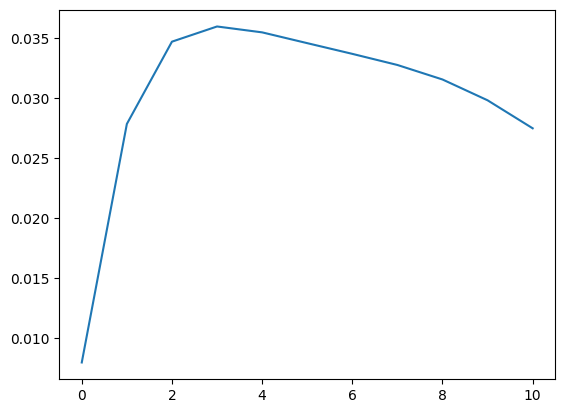

In [21]:
err = solver.compute_error(u_ex, 'L2')
print(err)

import matplotlib.pyplot as plt
plt.plot(err)

We can now also repeat the positivity preserving experiment explained in [the positivity preserving notebook](Positivity-ADR) and verify mass preservation

In [22]:
T = 2
t = Parameter(0)
dt = Parameter(0.1)

simulation_pp = MovingProblem(mesh=mesh, t=t, dt = dt, T = T)

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0, 0, 0))
phi, inv_phi, w_phi, detJ, n_ex = get_lin_trans_params(A, B, t)
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))

def displacement_pp():
        return displ_ex
simulation_pp.set_displacement(displacement_pp)

solver_pp = ADRSolver()
simulation_pp.attach_solver(solver_pp)

b_pp = 2*P_ex*CF((-z,0,x))
d_pp = CF(0.0)
u0 = exp(-2*(x**2+y**2))
Draw(u0, mesh)
Fflux = CF((0,0,0))
Fflux_c_bc = {'boundary': Fflux}
solver_pp.AddSpecie(VorB = BND,
                advection = b_pp,
                diffusion = d_pp,
                u0 = u0,
                Fflux_c_bc = Fflux_c_bc,
                MP = True)

simulation_pp.run()

print('Computed solution')
solver_pp.draw_solution()

mass0 = Integrate(u0, mesh, BND, order = 3)
mesh.SetDeformation(simulation_pp.data['dX'])
mass_end = Integrate(solver_pp.get_solution(), mesh, BND, order = 3)
mesh.UnsetDeformation()

print('Relative mass error: ', (mass_end-mass0)/mass0)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Running Simulation...:   0%|                        | 0/20 [00:00<?, ?it/s]

Running Simulation...: 100%|███████████████| 20/20 [00:00<00:00, 31.66it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Relative mass error:  -5.077429889473922e-06
